# 05 EDA — 데이터와 시세 요인

목적: PPT의 데이터·시세 요인 장에 쓸 그림을 여러 열·조합으로 그려 보고, 의미 있는 것을 고른다. 판단은 `docs/의사결정/1007_14_변수_정리.md`·`1007_15`.

- 가격 비교는 시점 차이를 빼기 위해 **기준일 환산 가격**(구별 시점 지수, 1007_08)으로 한다. 시세 요인은 모델이 쓰는 **최근 3년** 거래(1007_13), 거래량·시점 지수는 수집 전체 6년
- **실거래/공시 비율**은 "공시가격이 시세를 얼마나 덜 반영했나" — 모델(B1)이 쓰는 값이라, 요인별 비율 차이가 곧 ML 보정이 필요한 이유다
- 색: 권역 3개는 고정 순서(강서 화곡 = 파랑, 관악 = 주황, 강남 = 청록). 값 크기는 파랑 한 가지 색의 진하기


In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from avm import load_refs, add_location, TimeIndex, SGG_NAME, BASE_DATE, PROC
from ml import load_buildings
FIG = ROOT / "outputs" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

# 차트 공통 스타일(dataviz 기준 팔레트: 권역 3색은 모든 쌍 색각 검증 통과, 청록은 대비가 낮아 범례·직접 라벨 필수)
INK, INK2, MUTED, SURF, GRID = "#0b0b0b", "#52514e", "#8a8984", "#fcfcfb", "#e6e5e1"
SGG_ORDER = ["강서구", "관악구", "강남구"]
COL = {"강서구": "#2a78d6", "관악구": "#eb6834", "강남구": "#1baf7a"}
LABEL = {"강서구": "강서 화곡동", "관악구": "관악구", "강남구": "강남구"}
SEQ = mpl.colors.LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#104281", "#0d366b"])
DIV = mpl.colors.LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])
plt.rcParams.update({"font.family": "Malgun Gothic", "axes.unicode_minus": False, "figure.facecolor": SURF, "axes.facecolor": SURF,
                     "savefig.facecolor": SURF, "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
                     "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "axes.titlelocation": "left", "legend.frameon": False, "figure.dpi": 110, "savefig.dpi": 160})
def save(fig, name):
    fig.savefig(FIG / f"eda_{name}.png", bbox_inches="tight"); plt.show()
def won(x):  # 억 단위 축
    return f"{x / 1e8:.1f}억"

refs = load_refs()                                   # 최근 3년(모델 학습 기간)
t = refs.trades.copy()
t = t[(t.sgg_cd != "11500") | (t.dong == "화곡동")].copy()   # 평가 권역만(강서는 화곡동)
ti = TimeIndex().fit(refs.trades)
t["adj"] = np.exp(ti.adjust(t.sgg_cd.to_numpy(), t.deal_date))
t["price_adj"] = t.price * t.adj                      # 기준일 환산 실거래가
t["m2_adj"] = t.price_adj / t.area_m2 / 1e4           # 기준일 환산 ㎡당 가격(만원)
t["ratio"] = np.where(t.public_year == 2026, t.price_adj / t.price_public, np.nan)  # 기준일 환산 실거래/2026 공시
t["권역"] = t.sgg_cd.map(SGG_NAME)
b = load_buildings(t); t = t.join(b[["elevator", "grnd_flr", "hhld_cnt"]].rename(columns=lambda c: "b_" + c), on="pnu")
t = add_location(t, refs)
t["연식"] = BASE_DATE.year - t.pnu.map(b.build_year)
full = pd.read_csv(PROC / "trades.csv", dtype={"pnu": str, "sgg_cd": str}, parse_dates=["deal_date"], low_memory=False)
full = full[(full.sgg_cd != "11500") | (full.dong == "화곡동")].assign(권역=lambda d: d.sgg_cd.map(SGG_NAME))
print(f"최근 3년 평가 권역 거래 {len(t):,}건(2026 공시 비율 {t.ratio.notna().sum():,}), 6년 {len(full):,}건")
t.groupby("권역")[["m2_adj", "ratio", "area_m2", "연식"]].median().round(2)

최근 3년 평가 권역 거래 11,990건(2026 공시 비율 11,713), 6년 28,121건


,m2_adj,ratio,area_m2,연식
권역,,,,
강남구,1584.36,1.88,32.74,12.0
강서구,498.54,1.68,42.34,18.0
관악구,677.24,1.80,44.50,24.0


## A. 데이터 개요

### A1. 월별 거래량 (6년) — 시장 사이클

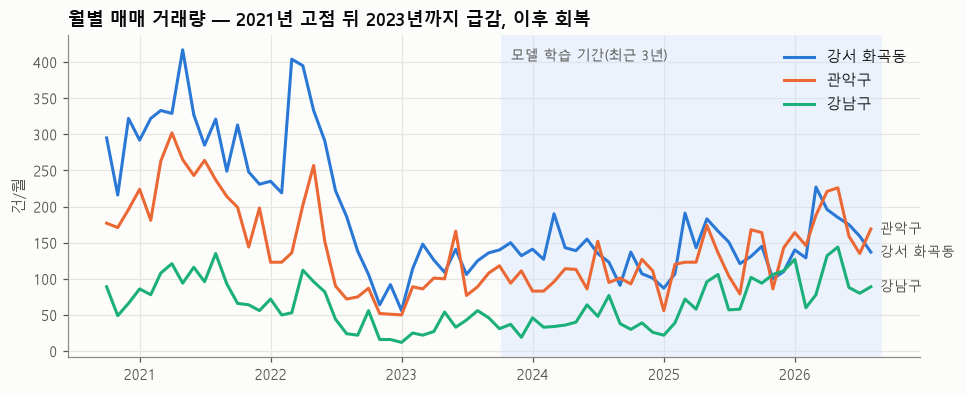

권역            강남구     강서구     관악구
deal_date                        
2020        204.0   833.0   544.0
2021       1113.0  3667.0  2734.0
2022        643.0  2685.0  1420.0
2023        405.0  1483.0  1189.0
2024        511.0  1589.0  1254.0
2025        921.0  1635.0  1476.0
2026        798.0  1348.0  1408.0


In [2]:
m = full.groupby([full.deal_date.dt.to_period("M"), "권역"]).size().unstack().loc[:"2026-08"]
fig, ax = plt.subplots(figsize=(10, 3.8))
for g in SGG_ORDER:
    s = m[g]; ax.plot(s.index.to_timestamp(), s.values, color=COL[g], lw=2, label=LABEL[g])
    ax.annotate(LABEL[g], (s.index[-1].to_timestamp(), s.values[-1]), xytext=(6, 0), textcoords="offset points", color=INK2, va="center", fontsize=9)
ax.axvspan(pd.Timestamp("2023-10-06"), pd.Timestamp("2026-08-31"), color="#cde2fb", alpha=0.35, lw=0)
ax.text(pd.Timestamp("2023-11-01"), ax.get_ylim()[1] * 0.92, "모델 학습 기간(최근 3년)", color=INK2, fontsize=9)
ax.set_title("월별 매매 거래량 — 2021년 고점 뒤 2023년까지 급감, 이후 회복"); ax.set_ylabel("건/월"); ax.legend(loc="upper right")
save(fig, "A1_monthly_volume")
print(m.resample("Y").sum() if hasattr(m, "resample") else m.groupby(m.index.year).sum())

### A2. 권역별 ㎡당 가격 분포 (기준일 환산, 최근 3년)

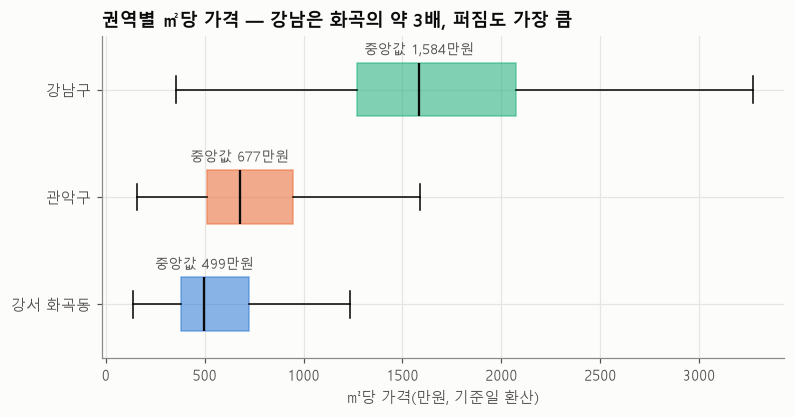

,count,mean,std,min,10%,50%,90%,max
권역,,,,,,,,
강남구,2359.0,1739.0,721.0,355.0,1013.0,1584.0,2668.0,9321.0
강서구,5093.0,571.0,248.0,136.0,315.0,499.0,908.0,1739.0
관악구,4538.0,757.0,337.0,160.0,418.0,677.0,1160.0,3260.0


In [3]:
fig, ax = plt.subplots(figsize=(8, 3.8))
data = [t.loc[t.권역 == g, "m2_adj"].clip(upper=4000) for g in SGG_ORDER]
bp = ax.boxplot(data, orientation="horizontal", widths=0.5, patch_artist=True, showfliers=False, medianprops={"color": INK, "lw": 1.5})
for patch, g in zip(bp["boxes"], SGG_ORDER):
    patch.set_facecolor(COL[g]); patch.set_alpha(0.55); patch.set_edgecolor(COL[g])
for i, g in enumerate(SGG_ORDER, 1):
    med = t.loc[t.권역 == g, "m2_adj"].median(); ax.text(med, i + 0.33, f"중앙값 {med:,.0f}만원", ha="center", fontsize=9, color=INK2)
ax.set_yticks([1, 2, 3], [LABEL[g] for g in SGG_ORDER]); ax.set_xlabel("㎡당 가격(만원, 기준일 환산)")
ax.set_title("권역별 ㎡당 가격 — 강남은 화곡의 약 3배, 퍼짐도 가장 큼")
save(fig, "A2_m2_price_by_sgg")
t.groupby("권역").m2_adj.describe(percentiles=[.1, .5, .9]).round(0)

### A3. 전용면적·연식 분포

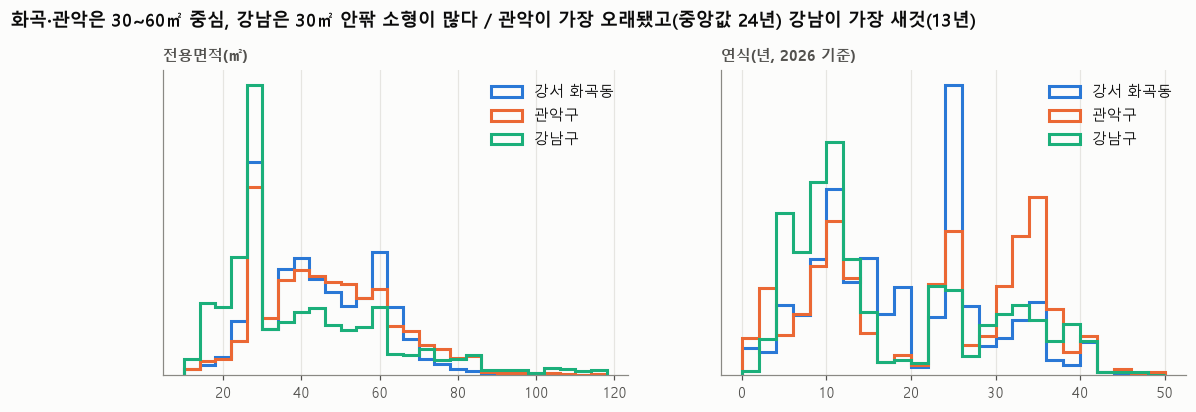

area_m2                                                 연식              \
      count  mean   std   min   25%   50%   75%    max   count  mean   std   
권역                                                                           
강남구  2359.0  44.8  32.4  12.1  26.6  32.7  55.0  245.0  2359.0  16.9  11.3   
강서구  5093.0  44.2  14.9  12.2  30.0  42.3  56.7  137.9  5093.0  18.6   9.8   
관악구  4538.0  46.6  17.2  11.6  32.5  44.5  57.8  159.4  4538.0  21.3  12.1   

                                  
     min   25%   50%   75%   max  
권역                                
강남구  0.0   8.0  12.0  26.0  46.0  
강서구  0.0  10.0  18.0  25.0  49.0  
관악구  0.0  10.0  24.0  33.0  55.0

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for g in SGG_ORDER:
    d = t[t.권역 == g]
    axes[0].hist(d.area_m2.clip(upper=120), bins=np.arange(10, 122, 4), histtype="step", lw=2, color=COL[g], label=LABEL[g], density=True)
    axes[1].hist(d.연식.dropna().clip(upper=50), bins=np.arange(0, 52, 2), histtype="step", lw=2, color=COL[g], label=LABEL[g], density=True)
axes[0].set_title("전용면적(㎡)", fontsize=10, color=INK2); axes[0].legend()
axes[1].set_title("연식(년, 2026 기준)", fontsize=10, color=INK2); axes[1].legend()
fig.suptitle("화곡·관악은 30~60㎡ 중심, 강남은 30㎡ 안팎 소형이 많다 / 관악이 가장 오래됐고(중앙값 24년) 강남이 가장 새것(13년)",
             x=0.01, y=1.03, ha="left", fontweight="bold", fontsize=12)
for a in axes: a.set_yticks([])
save(fig, "A3_area_age_dist")
t.groupby("권역")[["area_m2", "연식"]].describe().round(1)

## B. 공시가격과 시세 — 모델의 뼈대

### B1. 실거래가 vs 공시가격 — 한 줄로 늘어선다

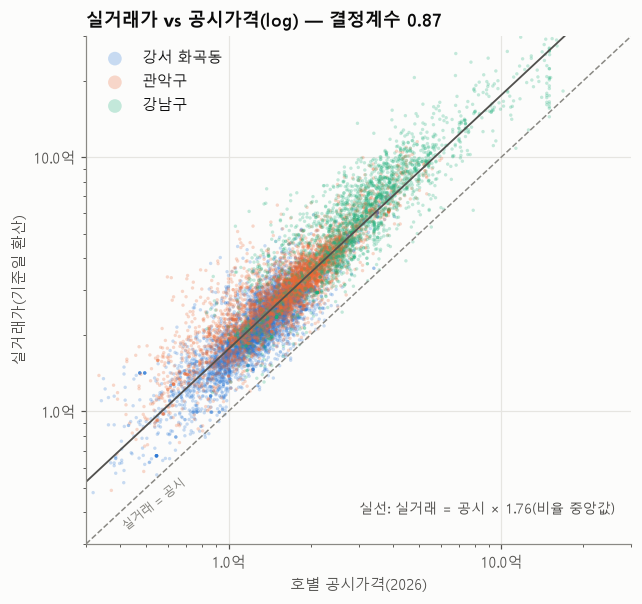

log 상관 결정계수 0.868, 비율 중앙값 1.756


In [5]:
d = t[t.ratio.notna()]
fig, ax = plt.subplots(figsize=(6.4, 6))
for g in SGG_ORDER:
    s = d[d.권역 == g]; ax.scatter(s.price_public, s.price_adj, s=5, alpha=0.25, color=COL[g], label=LABEL[g], edgecolors="none")
lim = [3e7, 3e9]; ax.plot(lim, lim, color=MUTED, lw=1, ls="--"); ax.text(4e7, 3.4e7, "실거래 = 공시", color=MUTED, fontsize=8, rotation=38)
med = d.ratio.median(); ax.plot(lim, [x * med for x in lim], color=INK2, lw=1.2)
ax.text(0.97, 0.06, f"실선: 실거래 = 공시 × {med:.2f}(비율 중앙값)", transform=ax.transAxes, color=INK2, fontsize=9, ha="right")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(lim)
fmt = mpl.ticker.FuncFormatter(lambda x, _: won(x)); ax.xaxis.set_major_formatter(fmt); ax.yaxis.set_major_formatter(fmt)
r2 = np.corrcoef(np.log(d.price_public), np.log(d.price_adj))[0, 1] ** 2
ax.set_title(f"실거래가 vs 공시가격(log) — 결정계수 {r2:.2f}"); ax.set_xlabel("호별 공시가격(2026)"); ax.set_ylabel("실거래가(기준일 환산)")
leg = ax.legend(markerscale=4, loc="upper left")
save(fig, "B1_price_vs_public")
print(f"log 상관 결정계수 {r2:.3f}, 비율 중앙값 {med:.3f}")

### B2. 무엇이 가격을 설명하나 — 변수 하나씩의 설명력(결정계수)

log 실거래가를 변수 하나(또는 구)로만 회귀했을 때 설명되는 비율. 공시가격 하나가 면적·위치·연식을 합친 것보다 많이 설명한다

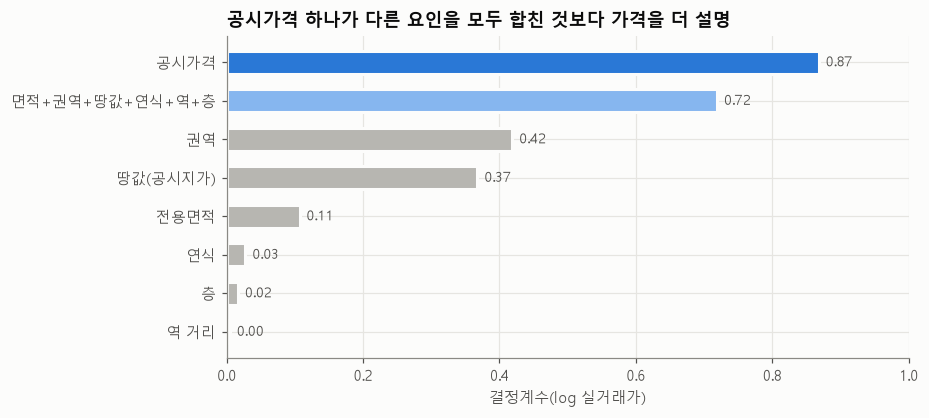

역 거리               0.005
층                  0.017
연식                 0.027
전용면적               0.107
땅값(공시지가)           0.368
권역                 0.419
면적+권역+땅값+연식+역+층    0.719
공시가격               0.868
dtype: float64

In [6]:
d = t[t.ratio.notna()].dropna(subset=["land_price_m2", "station_dist_m", "연식"]).copy()
y = np.log(d.price_adj)
def r2(cols):
    X = np.column_stack([np.ones(len(d))] + [c for c in cols]); beta = np.linalg.lstsq(X, y, rcond=None)[0]
    return 1 - ((y - X @ beta) ** 2).sum() / ((y - y.mean()) ** 2).sum()
dummies = [ (d.권역 == g).astype(float) for g in SGG_ORDER[1:] ]
cands = {"공시가격": [np.log(d.price_public)], "전용면적": [np.log(d.area_m2)], "권역": dummies, "땅값(공시지가)": [np.log(d.land_price_m2)],
         "연식": [d.연식], "역 거리": [np.log(d.station_dist_m + 50)], "층": [d.floor],
         "면적+권역+땅값+연식+역+층": [np.log(d.area_m2), *dummies, np.log(d.land_price_m2), d.연식, np.log(d.station_dist_m + 50), d.floor]}
res = pd.Series({k: r2(v) for k, v in cands.items()}).sort_values()
fig, ax = plt.subplots(figsize=(8, 3.8))
colors = ["#2a78d6" if k == "공시가격" else ("#86b6ef" if "+" in k else "#b7b6b1") for k in res.index]
ax.barh(res.index, res.values, color=colors, height=0.6, edgecolor=SURF, lw=2)
for i, v in enumerate(res.values): ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9, color=INK2)
ax.set_xlim(0, 1); ax.set_xlabel("결정계수(log 실거래가)"); ax.set_title("공시가격 하나가 다른 요인을 모두 합친 것보다 가격을 더 설명")
save(fig, "B2_r2_single_features")
res.round(3)

### B3. 실거래/공시 비율 분포 — 공시가격은 시세의 약 60%

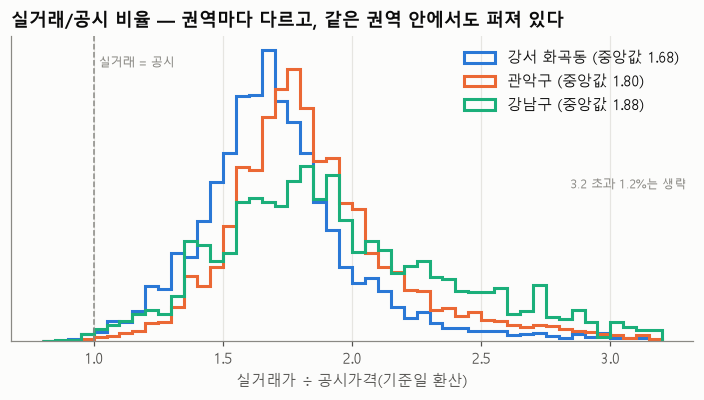

,count,mean,std,min,10%,50%,90%,max
권역,,,,,,,,
강남구,2246.0,1.970,0.528,0.783,1.405,1.878,2.656,7.610
강서구,5018.0,1.717,0.333,0.925,1.363,1.680,2.086,4.437
관악구,4449.0,1.881,0.413,0.991,1.507,1.803,2.329,5.655


In [7]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for g in SGG_ORDER:
    s = t.loc[(t.권역 == g), "ratio"].dropna()
    ax.hist(s[s.between(0.8, 3.2)], bins=np.arange(0.8, 3.25, 0.05), histtype="step", lw=2, color=COL[g], label=f"{LABEL[g]} (중앙값 {s.median():.2f})", density=True)
ax.text(0.99, 0.5, f"3.2 초과 {(t.ratio > 3.2).mean():.1%}는 생략", transform=ax.transAxes, ha="right", fontsize=8, color=MUTED)
ax.axvline(1, color=MUTED, lw=1, ls="--"); ax.text(1.02, ax.get_ylim()[1] * 0.9, "실거래 = 공시", color=MUTED, fontsize=8)
ax.set_yticks([]); ax.set_xlabel("실거래가 ÷ 공시가격(기준일 환산)"); ax.set_title("실거래/공시 비율 — 권역마다 다르고, 같은 권역 안에서도 퍼져 있다"); ax.legend()
save(fig, "B3_ratio_dist")
t.groupby("권역").ratio.describe(percentiles=[.1, .5, .9]).round(3)

### B4. 시점 지수 — 6년 동안의 시장 변화(구별, 2026-08 = 1.0)

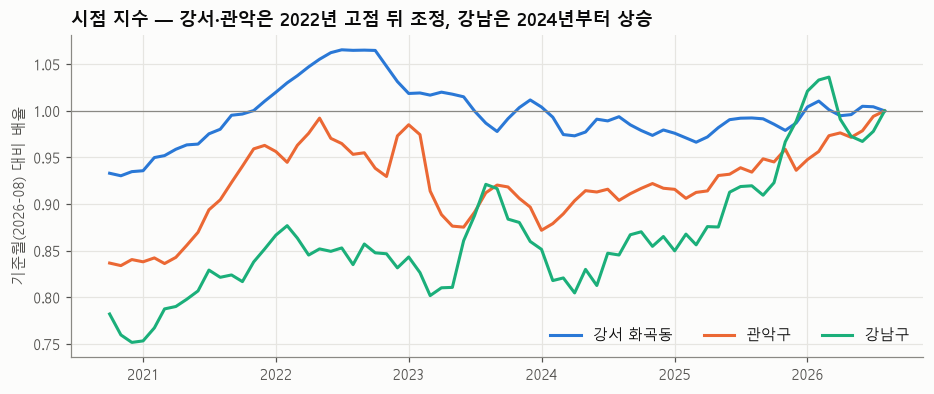

,강서구,관악구,강남구
2020-10,0.933,0.837,0.782
2021-04,0.959,0.843,0.790
2021-10,0.997,0.941,0.817
2022-04,1.047,0.976,0.845
2022-10,1.065,0.938,0.848
2023-04,1.020,0.889,0.810
2023-10,0.992,0.918,0.884
2024-04,0.973,0.904,0.805
2024-10,0.979,0.917,0.870
2025-04,0.972,0.914,0.876


In [8]:
ti6 = TimeIndex().fit(full)
rel = np.exp(ti6.index - ti6.index.iloc[-1]); rel.columns = [SGG_NAME[c] for c in rel.columns]
fig, ax = plt.subplots(figsize=(10, 3.8))
for g in SGG_ORDER:
    s = rel[g]; ax.plot(s.index.to_timestamp(), s.values, color=COL[g], lw=2, label=LABEL[g])
ax.axhline(1, color=MUTED, lw=0.8); ax.set_ylabel("기준월(2026-08) 대비 배율")
ax.set_title("시점 지수 — 강서·관악은 2022년 고점 뒤 조정, 강남은 2024년부터 상승"); ax.legend(loc="lower right", ncol=3)
save(fig, "B4_time_index")
rel.iloc[::6].round(3)

## C. 시세 요인 — 요인 × 권역

각 요인을 **㎡당 가격**(시세 수준)과 **실거래/공시 비율**(공시가격이 덜 반영한 정도) 두 가지로 본다. 비율이 요인에 따라 달라지면 공시가격만으로는 부족하다는 뜻이다

In [9]:
def factor_plot(col, bins, labels, name, title, min_n=30):
    d = t.assign(구간=pd.cut(t[col], bins, labels=labels))
    agg = d.groupby(["권역", "구간"], observed=True).agg(m2=("m2_adj", "median"), ratio=("ratio", "median"), n=("m2_adj", "size")).reset_index()
    agg = agg[agg.n >= min_n]
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    x = {l: i for i, l in enumerate(labels)}
    for g in SGG_ORDER:
        s = agg[agg.권역 == g]
        for ax, v in zip(axes, ["m2", "ratio"]):
            ax.plot([x[c] for c in s.구간], s[v], color=COL[g], lw=2, marker="o", ms=6, mec=SURF, mew=2, label=LABEL[g])
    for ax, ttl in zip(axes, ["㎡당 가격 중앙값(만원)", "실거래/공시 비율 중앙값"]):
        ax.set_xticks(range(len(labels)), labels); ax.set_title(ttl, fontsize=10, color=INK2, loc="left"); ax.legend(fontsize=8)
    fig.suptitle(title, x=0.01, y=1.03, ha="left", fontweight="bold", fontsize=12)
    save(fig, name)
    return agg.pivot(index="구간", columns="권역", values=["m2", "ratio", "n"]).round(2)

### C1. 연식

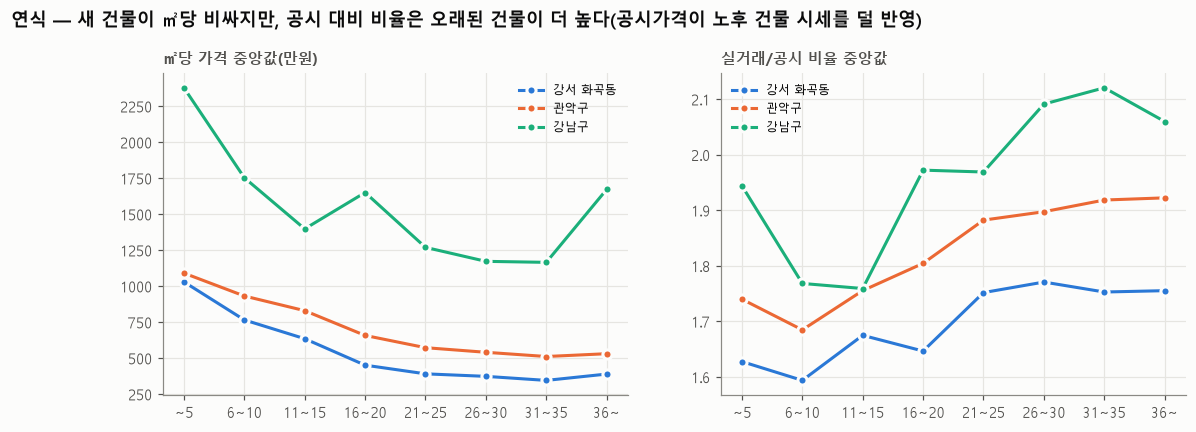

m2                   ratio                  n                
권역         강남구      강서구      관악구   강남구   강서구   관악구    강남구     강서구     관악구
구간                                                                       
~5     2379.02  1030.85  1091.68  1.94  1.63  1.74  314.0   401.0   488.0
6~10   1754.28   766.54   932.79  1.77  1.59  1.68  743.0   967.0   754.0
11~15  1399.16   636.12   830.81  1.76  1.68  1.76  382.0   948.0   624.0
16~20  1651.62   452.38   658.80  1.97  1.65  1.80   53.0   511.0   117.0
21~25  1270.56   392.07   573.77  1.97  1.75  1.88  276.0  1178.0   713.0
26~30  1173.51   374.60   541.81  2.09  1.77  1.90  156.0   393.0   359.0
31~35  1166.52   346.52   512.46  2.12  1.75  1.92  239.0   486.0  1055.0
36~    1673.21   390.53   531.93  2.06  1.76  1.92  196.0   209.0   428.0

In [10]:
factor_plot("연식", [-1, 5, 10, 15, 20, 25, 30, 35, 60], ["~5", "6~10", "11~15", "16~20", "21~25", "26~30", "31~35", "36~"], "C1_age",
            "연식 — 새 건물이 ㎡당 비싸지만, 공시 대비 비율은 오래된 건물이 더 높다(공시가격이 노후 건물 시세를 덜 반영)")

### C2. 층

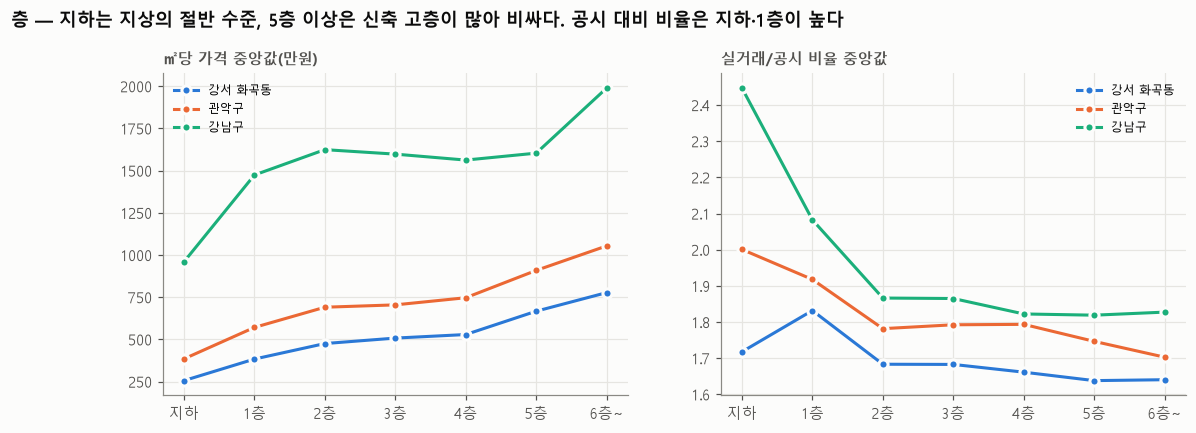

m2                  ratio                  n                
권역       강남구     강서구      관악구   강남구   강서구   관악구    강남구     강서구     관악구
구간                                                                    
지하    959.37  255.79   384.59  2.45  1.72  2.00  109.0   284.0   417.0
1층   1473.86  383.45   570.94  2.08  1.83  1.92  223.0   484.0   696.0
2층   1624.11  475.35   690.59  1.87  1.68  1.78  579.0  1164.0  1124.0
3층   1597.56  507.75   704.53  1.86  1.68  1.79  580.0  1126.0   977.0
4층   1562.34  528.78   746.80  1.82  1.66  1.79  470.0  1000.0   710.0
5층   1603.40  667.06   908.65  1.82  1.64  1.75  285.0   614.0   397.0
6층~  1989.21  777.16  1053.82  1.83  1.64  1.70  113.0   421.0   217.0

In [11]:
factor_plot("floor", [-5, 0, 1, 2, 3, 4, 5, 30], ["지하", "1층", "2층", "3층", "4층", "5층", "6층~"], "C2_floor",
            "층 — 지하는 지상의 절반 수준, 5층 이상은 신축 고층이 많아 비싸다. 공시 대비 비율은 지하·1층이 높다")

### C3. 전용면적

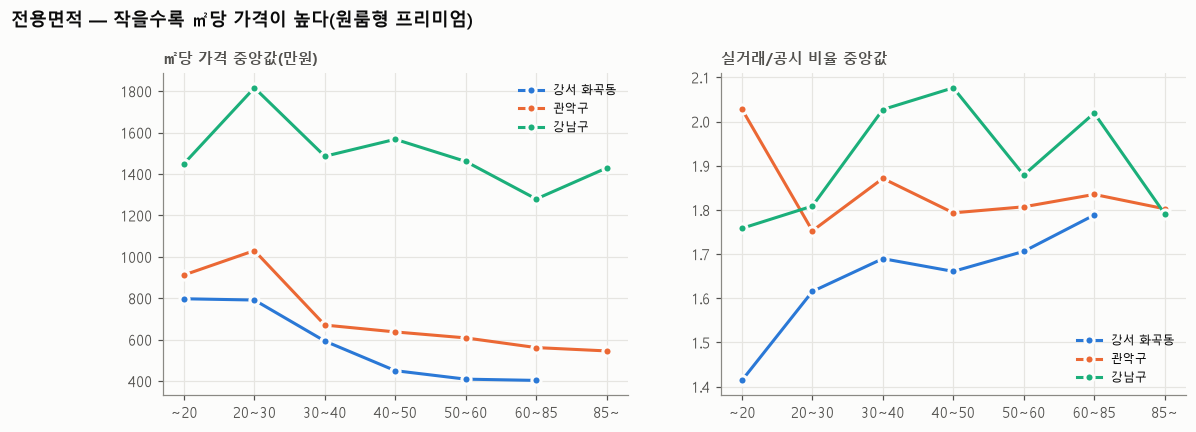

m2                  ratio                  n               
권역         강남구     강서구      관악구   강남구   강서구   관악구    강남구     강서구    관악구
구간                                                                     
~20    1449.33  797.26   911.95  1.76  1.41  2.03  248.0   100.0   94.0
20~30  1815.98  791.15  1029.91  1.81  1.62  1.75  866.0  1224.0  924.0
30~40  1485.28  592.89   670.31  2.03  1.69  1.87  239.0   928.0  779.0
40~50  1567.37  450.07   637.16  2.08  1.66  1.79  303.0  1030.0  967.0
50~60  1460.28  409.09   608.31  1.88  1.71  1.81  289.0   969.0  865.0
60~85  1279.11  403.10   561.55  2.02  1.79  1.83  262.0   827.0  845.0
85~    1428.92     NaN   545.40  1.79   NaN  1.80  152.0     NaN   64.0

In [12]:
factor_plot("area_m2", [0, 20, 30, 40, 50, 60, 85, 300], ["~20", "20~30", "30~40", "40~50", "50~60", "60~85", "85~"], "C3_area",
            "전용면적 — 작을수록 ㎡당 가격이 높다(원룸형 프리미엄)")

### C4. 지하철역 거리

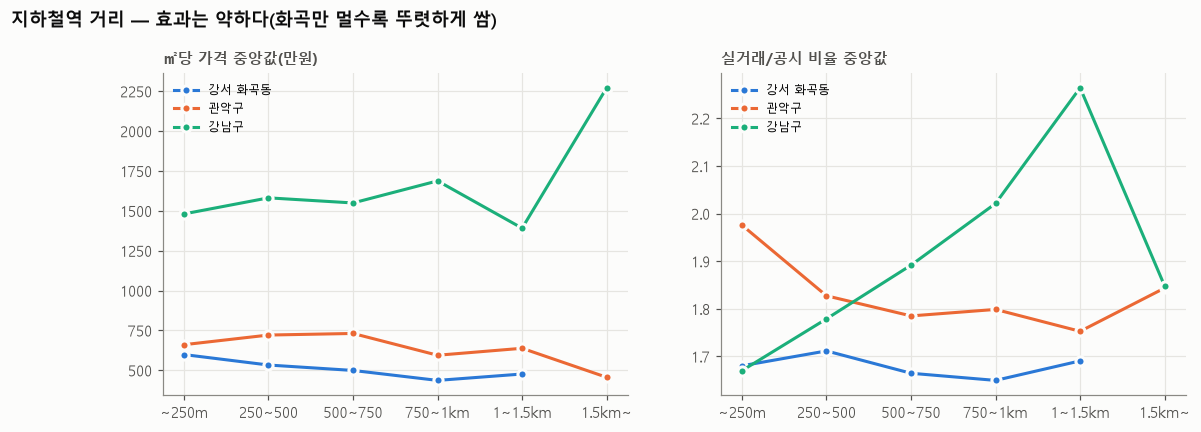

m2                 ratio                   n                
권역           강남구     강서구     관악구   강남구   강서구   관악구     강남구     강서구     관악구
구간                                                                        
~250m    1480.76  598.88  660.72  1.67  1.68  1.98   129.0   327.0   282.0
250~500  1581.54  533.24  721.23  1.78  1.71  1.83  1045.0  1563.0  1262.0
500~750  1549.49  499.25  731.14  1.89  1.66  1.79   437.0  1677.0  1353.0
750~1km  1687.89  436.85  594.57  2.02  1.65  1.80   408.0   925.0   928.0
1~1.5km  1391.31  476.94  638.25  2.26  1.69  1.75   297.0   601.0   638.0
1.5km~   2271.62     NaN  456.31  1.85   NaN  1.84    43.0     NaN    75.0

In [13]:
factor_plot("station_dist_m", [0, 250, 500, 750, 1000, 1500, 5000], ["~250m", "250~500", "500~750", "750~1km", "1~1.5km", "1.5km~"], "C4_station",
            "지하철역 거리 — 효과는 약하다(화곡만 멀수록 뚜렷하게 쌈)")

### C5. 승강기 × 권역

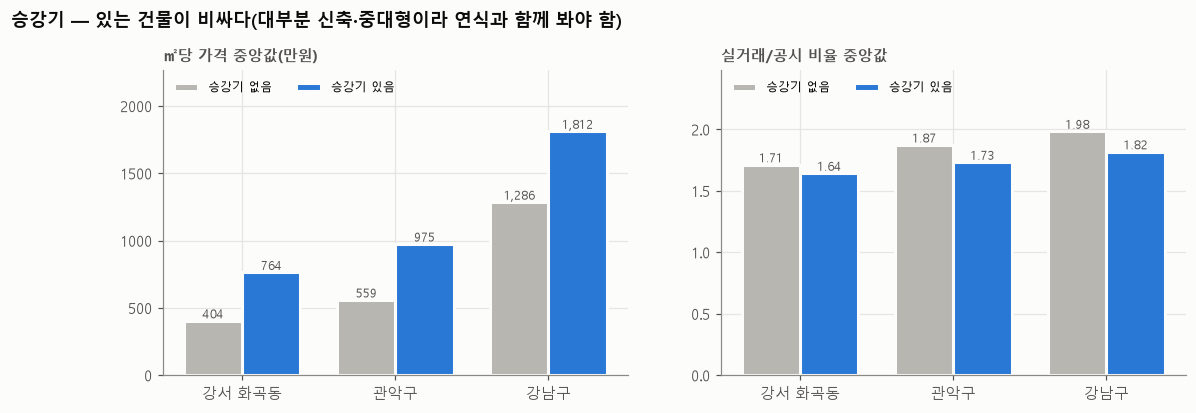

,권역,승강기,m2,ratio,n,연식
0,강남구,없음,1285.76,1.98,995,28.0
1,강남구,있음,1812.22,1.82,1364,9.0
2,강서구,없음,403.96,1.71,3068,24.0
3,강서구,있음,763.86,1.64,2005,10.0
4,관악구,없음,558.85,1.87,2943,31.0
5,관악구,있음,974.79,1.73,1594,9.0


In [14]:
d = t.dropna(subset=["b_elevator"]).assign(승강기=lambda x: np.where(x.b_elevator.astype(bool), "있음", "없음"))
agg = d.groupby(["권역", "승강기"]).agg(m2=("m2_adj", "median"), ratio=("ratio", "median"), n=("m2_adj", "size"), 연식=("연식", "median")).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
w = 0.38
for j, (v, ttl) in enumerate([("m2", "㎡당 가격 중앙값(만원)"), ("ratio", "실거래/공시 비율 중앙값")]):
    for k, e in enumerate(["없음", "있음"]):
        s = agg[agg.승강기 == e].set_index("권역").loc[SGG_ORDER]
        bars = axes[j].bar(np.arange(3) + (k - 0.5) * w, s[v], width=w, color=["#b7b6b1", "#2a78d6"][k], edgecolor=SURF, lw=2, label=f"승강기 {e}")
        for x0, val in zip(np.arange(3) + (k - 0.5) * w, s[v]): axes[j].text(x0, val, f"{val:,.0f}" if v == "m2" else f"{val:.2f}", ha="center", va="bottom", fontsize=8, color=INK2)
    axes[j].set_xticks(range(3), [LABEL[g] for g in SGG_ORDER]); axes[j].set_title(ttl, fontsize=10, color=INK2)
    axes[j].set_ylim(0, agg[v].max() * 1.25); axes[j].legend(fontsize=8, ncol=2, loc="upper left")
fig.suptitle("승강기 — 있는 건물이 비싸다(대부분 신축·중대형이라 연식과 함께 봐야 함)", x=0.01, y=1.03, ha="left", fontweight="bold", fontsize=12)
save(fig, "C5_elevator")
agg.round(2)

### C6. 땅값(㎡당 개별공시지가) vs ㎡당 가격

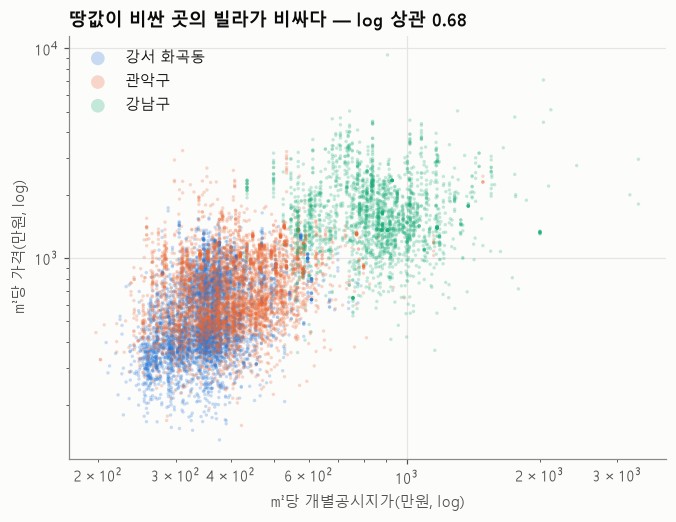

log 상관 0.684


In [15]:
d = t.dropna(subset=["land_price_m2"])
fig, ax = plt.subplots(figsize=(7, 5))
for g in SGG_ORDER:
    s = d[d.권역 == g]; ax.scatter(s.land_price_m2 / 1e4, s.m2_adj, s=5, alpha=0.25, color=COL[g], label=LABEL[g], edgecolors="none")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("㎡당 개별공시지가(만원, log)"); ax.set_ylabel("㎡당 가격(만원, log)")
rho = np.corrcoef(np.log(d.land_price_m2), np.log(d.m2_adj))[0, 1]
ax.set_title(f"땅값이 비싼 곳의 빌라가 비싸다 — log 상관 {rho:.2f}"); ax.legend(markerscale=4)
save(fig, "C6_land_vs_m2")
print(f"log 상관 {rho:.3f}")

### C7. 건물 규모(세대수)

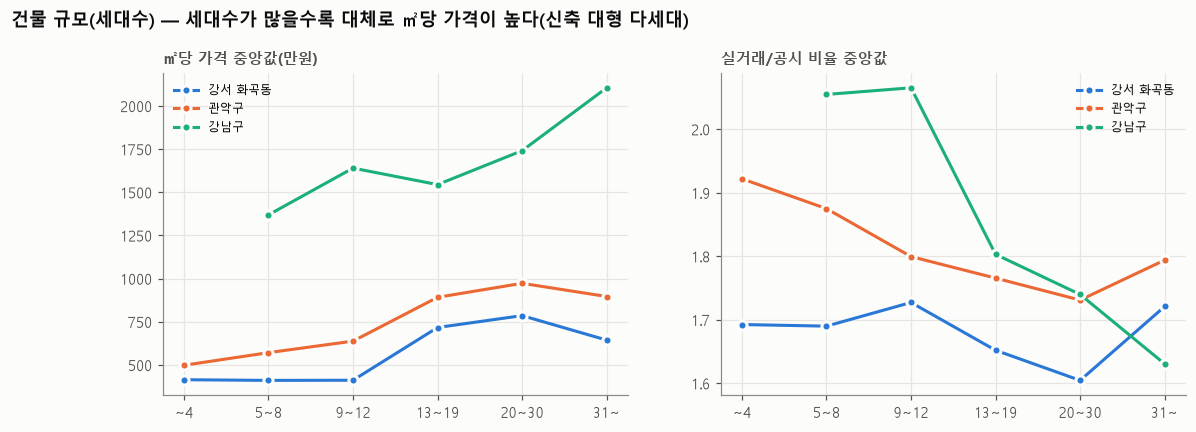

m2                 ratio                  n                
권역         강남구     강서구     관악구   강남구   강서구   관악구    강남구     강서구     관악구
구간                                                                     
~4         NaN  414.54  498.20   NaN  1.69  1.92    NaN    69.0   113.0
5~8    1369.49  410.58  571.36  2.05  1.69  1.87  458.0  1182.0  1398.0
9~12   1640.29  411.48  638.06  2.07  1.73  1.80  576.0  1783.0  1377.0
13~19  1544.79  717.01  891.89  1.80  1.65  1.77  745.0  1375.0  1130.0
20~30  1741.27  785.85  972.98  1.74  1.60  1.73  342.0   559.0   414.0
31~    2105.55  644.01  896.53  1.63  1.72  1.79  143.0   125.0   105.0

In [16]:
factor_plot("b_hhld_cnt", [0, 4, 8, 12, 19, 30, 400], ["~4", "5~8", "9~12", "13~19", "20~30", "31~"], "C7_households",
            "건물 규모(세대수) — 세대수가 많을수록 대체로 ㎡당 가격이 높다(신축 대형 다세대)")

### C8. 연식 × 면적 — ㎡당 가격 히트맵(권역별)

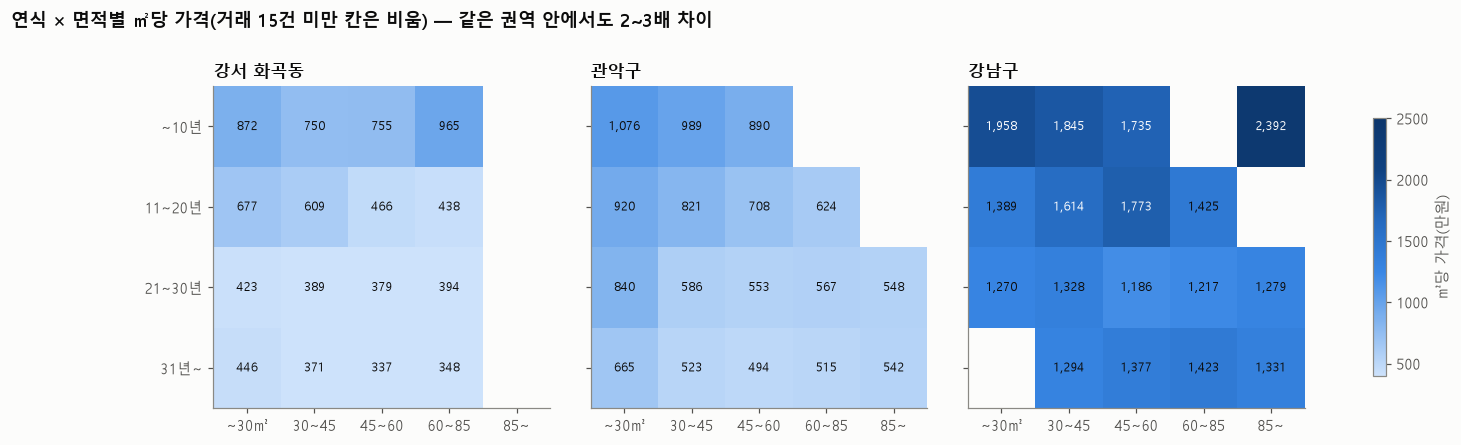

In [17]:
ab = pd.cut(t.연식, [-1, 10, 20, 30, 60], labels=["~10년", "11~20년", "21~30년", "31년~"])
arb = pd.cut(t.area_m2, [0, 30, 45, 60, 85, 300], labels=["~30㎡", "30~45", "45~60", "60~85", "85~"])
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8), gridspec_kw={"wspace": 0.12})
for k, (ax, g) in enumerate(zip(axes, SGG_ORDER)):
    m = t[t.권역 == g].assign(a=ab, r=arb).pivot_table(index="a", columns="r", values="m2_adj", aggfunc="median", observed=True)
    n = t[t.권역 == g].assign(a=ab, r=arb).pivot_table(index="a", columns="r", values="m2_adj", aggfunc="size", observed=True)
    m = m.where(n >= 15)
    im = ax.imshow(m.values, cmap=SEQ, aspect="auto", vmin=400, vmax=2500)
    ax.set_xticks(range(m.shape[1]), m.columns); ax.set_yticks(range(m.shape[0]), m.index if k == 0 else [""] * m.shape[0]); ax.grid(False)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            if pd.notna(m.values[i, j]): ax.text(j, i, f"{m.values[i, j]:,.0f}", ha="center", va="center", fontsize=8,
                                                 color="white" if m.values[i, j] > 1500 else INK)
    ax.set_title(LABEL[g], fontsize=11)
fig.colorbar(im, ax=axes, shrink=0.8, label="㎡당 가격(만원)")
fig.suptitle("연식 × 면적별 ㎡당 가격(거래 15건 미만 칸은 비움) — 같은 권역 안에서도 2~3배 차이", x=0.01, y=1.06, ha="left", fontweight="bold", fontsize=12)
save(fig, "C8_heat_age_area")

### C9. 지도 — 필지 좌표별 ㎡당 가격

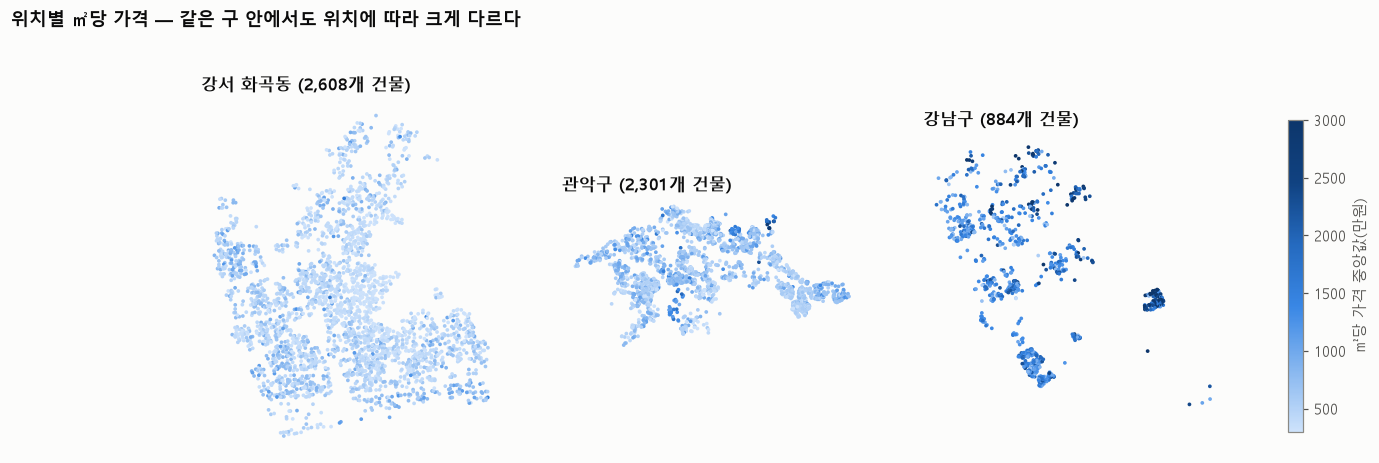

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, g in zip(axes, SGG_ORDER):
    s = t[(t.권역 == g)].dropna(subset=["lon"]).groupby("pnu").agg(lon=("lon", "first"), lat=("lat", "first"), m2=("m2_adj", "median"))
    sc = ax.scatter(s.lon, s.lat, c=s.m2.clip(300, 3000), cmap=SEQ, s=6, vmin=300, vmax=3000, edgecolors="none")
    ax.set_title(f"{LABEL[g]} ({len(s):,}개 건물)", fontsize=11); ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect(1 / np.cos(np.radians(37.5))); ax.grid(False); [sp.set_visible(False) for sp in ax.spines.values()]
fig.colorbar(sc, ax=axes, shrink=0.8, label="㎡당 가격 중앙값(만원)")
fig.suptitle("위치별 ㎡당 가격 — 같은 구 안에서도 위치에 따라 크게 다르다", x=0.01, y=1.02, ha="left", fontweight="bold", fontsize=12)
save(fig, "C9_map")

### C10. 변수 사이 상관 — 무엇이 서로 겹치나

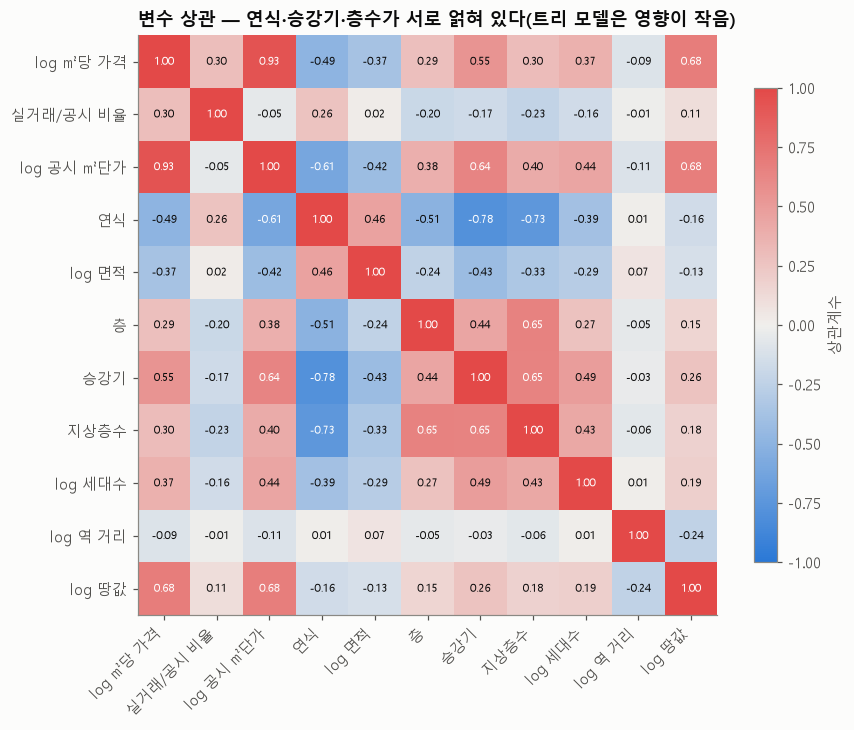

,log ㎡당 가격,실거래/공시 비율,log 공시 ㎡단가,연식,log 면적,층,승강기,지상층수,log 세대수,log 역 거리,log 땅값
log ㎡당 가격,1.00,0.30,0.93,-0.49,-0.37,0.29,0.55,0.30,0.37,-0.09,0.68
실거래/공시 비율,0.30,1.00,-0.05,0.26,0.02,-0.20,-0.17,-0.23,-0.16,-0.01,0.11
log 공시 ㎡단가,0.93,-0.05,1.00,-0.61,-0.42,0.38,0.64,0.40,0.44,-0.11,0.68
연식,-0.49,0.26,-0.61,1.00,0.46,-0.51,-0.78,-0.73,-0.39,0.01,-0.16
log 면적,-0.37,0.02,-0.42,0.46,1.00,-0.24,-0.43,-0.33,-0.29,0.07,-0.13
층,0.29,-0.20,0.38,-0.51,-0.24,1.00,0.44,0.65,0.27,-0.05,0.15
승강기,0.55,-0.17,0.64,-0.78,-0.43,0.44,1.00,0.65,0.49,-0.03,0.26
지상층수,0.30,-0.23,0.40,-0.73,-0.33,0.65,0.65,1.00,0.43,-0.06,0.18
log 세대수,0.37,-0.16,0.44,-0.39,-0.29,0.27,0.49,0.43,1.00,0.01,0.19
log 역 거리,-0.09,-0.01,-0.11,0.01,0.07,-0.05,-0.03,-0.06,0.01,1.00,-0.24


In [19]:
cols = {"log ㎡당 가격": np.log(t.m2_adj), "실거래/공시 비율": t.ratio, "log 공시 ㎡단가": np.log(t.price_public / t.area_m2), "연식": t.연식,
        "log 면적": np.log(t.area_m2), "층": t.floor, "승강기": t.b_elevator.astype(float), "지상층수": t.b_grnd_flr, "log 세대수": np.log1p(t.b_hhld_cnt),
        "log 역 거리": np.log(t.station_dist_m + 50), "log 땅값": np.log(t.land_price_m2)}
c = pd.DataFrame(cols).corr()
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(c.values, cmap=DIV, vmin=-1, vmax=1); ax.grid(False)
ax.set_xticks(range(len(c)), c.columns, rotation=45, ha="right"); ax.set_yticks(range(len(c)), c.columns)
for i in range(len(c)):
    for j in range(len(c)): ax.text(j, i, f"{c.values[i, j]:.2f}", ha="center", va="center", fontsize=7, color="white" if abs(c.values[i, j]) > 0.6 else INK)
fig.colorbar(im, ax=ax, shrink=0.8, label="상관계수")
ax.set_title("변수 상관 — 연식·승강기·층수가 서로 얽혀 있다(트리 모델은 영향이 작음)")
save(fig, "C10_corr")
c.round(2)

### C11. 거래유형 — 직거래는 공시가격 근처에서 거래된다

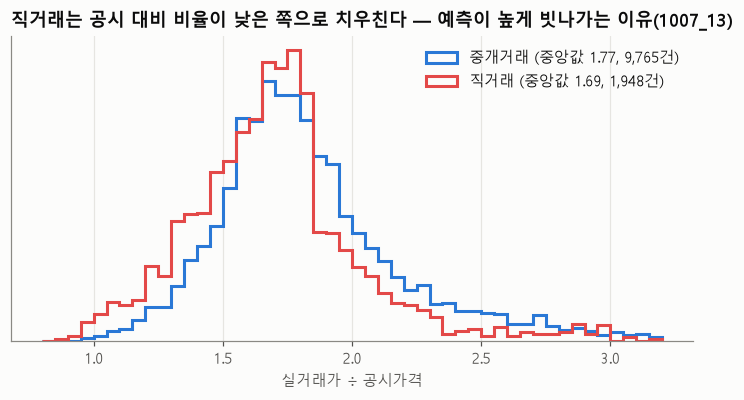

,count,mean,std,min,10%,50%,90%,max
dealing_type,,,,,,,,
중개거래,9765.0,1.851,0.423,0.939,1.444,1.771,2.357,7.610
직거래,1948.0,1.711,0.379,0.783,1.310,1.687,2.099,4.832


In [20]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for name, col in [("중개거래", "#2a78d6"), ("직거래", "#e34948")]:
    s = t.loc[t.dealing_type == name, "ratio"].dropna()
    ax.hist(s[s.between(0.8, 3.2)], bins=np.arange(0.8, 3.25, 0.05), histtype="step", lw=2, color=col, density=True, label=f"{name} (중앙값 {s.median():.2f}, {len(s):,}건)")
ax.set_yticks([]); ax.set_xlabel("실거래가 ÷ 공시가격"); ax.legend()
ax.set_title("직거래는 공시 대비 비율이 낮은 쪽으로 치우친다 — 예측이 높게 빗나가는 이유(1007_13)")
save(fig, "C11_dealing_type")
t.groupby("dealing_type").ratio.describe(percentiles=[.1, .5, .9]).round(3)

## D. 검증 요약 그림 (최종 모델, 저장된 검증 예측)

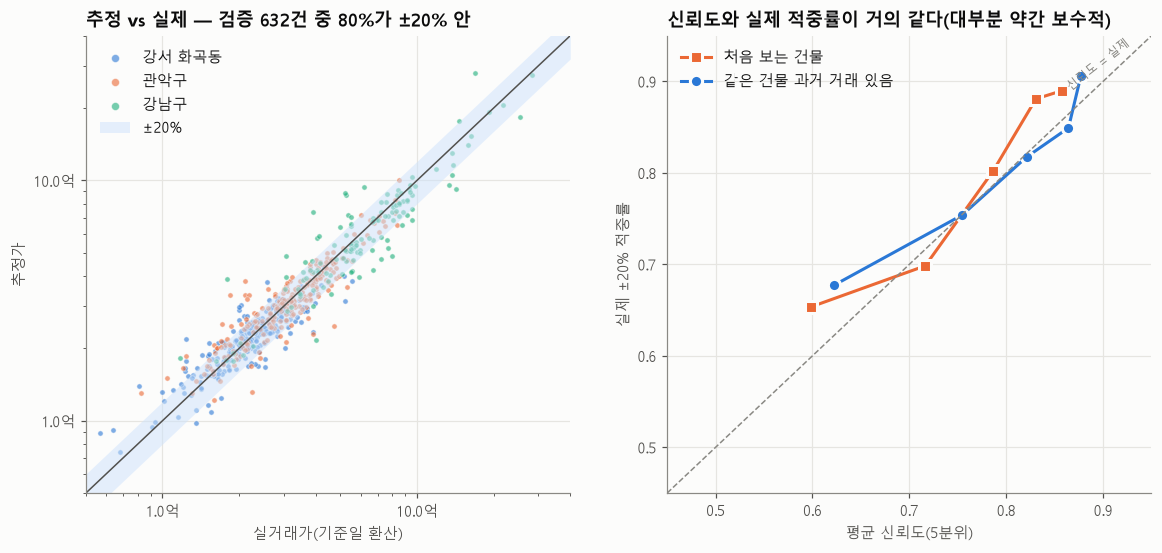

In [21]:
p = pd.read_csv(ROOT / "outputs" / "calibration_holdout_preds.csv", dtype={"pnu": str, "sgg_cd": str})
p = p[(p.구분 == "보정") & (~p.area_blank)].assign(권역=lambda d: d.sgg_cd.map(SGG_NAME))
q = p[p.상황 == "B"]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
ax = axes[0]
for g in SGG_ORDER:
    s = q[q.권역 == g]; ax.scatter(s.actual, s.price_est, s=12, alpha=0.6, color=COL[g], label=LABEL[g], edgecolors=SURF, linewidths=0.5)
lim = [5e7, 4e9]; xs = np.array(lim)
ax.plot(xs, xs, color=INK2, lw=1); ax.fill_between(xs, xs * 0.8, xs * 1.2, color="#cde2fb", alpha=0.5, lw=0, label="±20%")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(lim)
fmt = mpl.ticker.FuncFormatter(lambda x, _: won(x)); ax.xaxis.set_major_formatter(fmt); ax.yaxis.set_major_formatter(fmt)
ax.set_xlabel("실거래가(기준일 환산)"); ax.set_ylabel("추정가"); ax.legend(loc="upper left", markerscale=1.5)
ax.set_title(f"추정 vs 실제 — 검증 632건 중 {(q.ape <= .2).mean():.0%}가 ±20% 안")
ax = axes[1]
for sc, col, mk in [("A", "#eb6834", "s"), ("B", "#2a78d6", "o")]:
    g = p[p.상황 == sc]
    r = g.groupby(pd.qcut(g.confidence.rank(method="first"), 5), observed=True).agg(conf=("confidence", "mean"), hit=("ape", lambda v: (v <= .2).mean()))
    ax.plot(r.conf, r.hit, color=col, lw=2, marker=mk, ms=8, mec=SURF, mew=2, label={"A": "처음 보는 건물", "B": "같은 건물 과거 거래 있음"}[sc])
ax.plot([0.45, 0.95], [0.45, 0.95], color=MUTED, lw=1, ls="--"); ax.text(0.86, 0.89, "신뢰도 = 실제", color=MUTED, fontsize=8, rotation=38)
ax.set_xlim(0.45, 0.95); ax.set_ylim(0.45, 0.95); ax.set_xlabel("평균 신뢰도(5분위)"); ax.set_ylabel("실제 ±20% 적중률"); ax.legend(loc="upper left")
ax.set_title("신뢰도와 실제 적중률이 거의 같다(대부분 약간 보수적)")
save(fig, "D1_pred_vs_actual_reliability")

## 관찰

PPT에 쓸 그림 선택과 해석은 `docs/의사결정/1007_15_EDA.md`에 정리한다.